# Dataset Preparation

- input: curated briefsummary
- output: pd.series of ase objects pr pymatgen objects


In [1]:
import sys
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
import os
import pandas as pd
from BopFoxFeaturizer.Featurizer import Featurizer
from Tools.DatasetTools.Tools import need_to_update
from Tools.DatasetTools.SublatticeSorter import *
from pymatgen.io.ase import AseAtomsAdaptor

# options 

In [2]:
dataset = 'Fe-Mo'
case='POSCAR-initial' #, 'POSCAR-relaxed']
rescale_by_atoms=True #, False]
subcase = 'rescaled' # ,  'noscaled' ] 
Force= True
CuratedBS = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')

In [3]:
components = dataset.replace('-','')

In [4]:
BS = pd.read_pickle(CuratedBS)

In [5]:
Features = Featurizer(BS)

chech that the chemistry resetting is correct!

# Sort Poscar files

In [6]:
searchs = 'POSCAR.initial'
files = get_file_paths(dataset, searchs)
atomsobjectslocation = os.path.join(dataset,'Atomsobjects')
sublatticesortersfile = os.path.join(atomsobjectslocation, 'SORTERS.pkl')
sublatticetagfile = os.path.join(atomsobjectslocation, 'SUBLATICETAGS.pkl')

In [7]:
if need_to_update(sublatticesortersfile) or need_to_update(sublatticetagfile):
    SORTERS, SUBLATICETAGS = get_all_sorters_and_tags(dataset, files)
    SORTERS.to_pickle(sublatticesortersfile)
    SUBLATICETAGS.to_pickle(sublatticetagfile)
else:
    SORTERS = pd.read_pickle(sublatticesortersfile)
    SUBLATICETAGS = pd.read_pickle(sublatticetagfile)

0it [00:00, ?it/s]

# Now I have to pick the atoms objects

In [8]:
#for thiscase, (thisrescale, thissubcase) in product(case, zip(rescale_by_atoms, subcase)):
database = f'{dataset}/**/{case}'
AtomsFile = os.path.join(atomsobjectslocation,f'{components}-sorted-{case}-{subcase}-AtomsObjects.pkl')

In [9]:
if not need_to_update(AtomsFile):  #os.path.exists(AtomsFile) and not Force:
    Atoms_Objects = pd.read_pickle(AtomsFile)
else:
    Atoms_Objects, CantMake_Atoms_Object = Features.get_atoms_object(database=database,rescale_by_atoms=True, reset_chemistry=True,file_filter = 'sorted')
    Atoms_Objects.to_pickle(AtomsFile)
    Atoms_Objects.dropna(inplace=True)
pymatgenfile = AtomsFile.replace('AtomsObjects','PymatgenStructures')
Pymatgen_Structures = Atoms_Objects.copy()
if not need_to_update(pymatgenfile):
    Pymatgen_Structures = pd.read_pickle(pymatgenfile)
else:
    Pymatgen_Structures = Atoms_Objects['atoms'].apply(AseAtomsAdaptor.get_structure)
    Pymatgen_Structures['file'] = Atoms_Objects['file']
    Pymatgen_Structures.to_pickle(pymatgenfile)

  0%|          | 0/289 [00:00<?, ?it/s]

In [10]:
Atoms_Objects.atoms.isna().sum()

0

In [11]:
Atoms_Objects.to_pickle(AtomsFile)

In [12]:
accomodatewrap = Atoms_Objects.atoms.map(lambda a: a.wrap(pretty_translation=True))

In [13]:
difference = BS.index.difference(Atoms_Objects.index)

In [14]:
difference

Index([], dtype='object', name='index')

#  visualization of some structures

In [15]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('axes.spines', bottom=False, top=False, right=False, left=False)

In [16]:
from ase.visualize.plot import plot_atoms

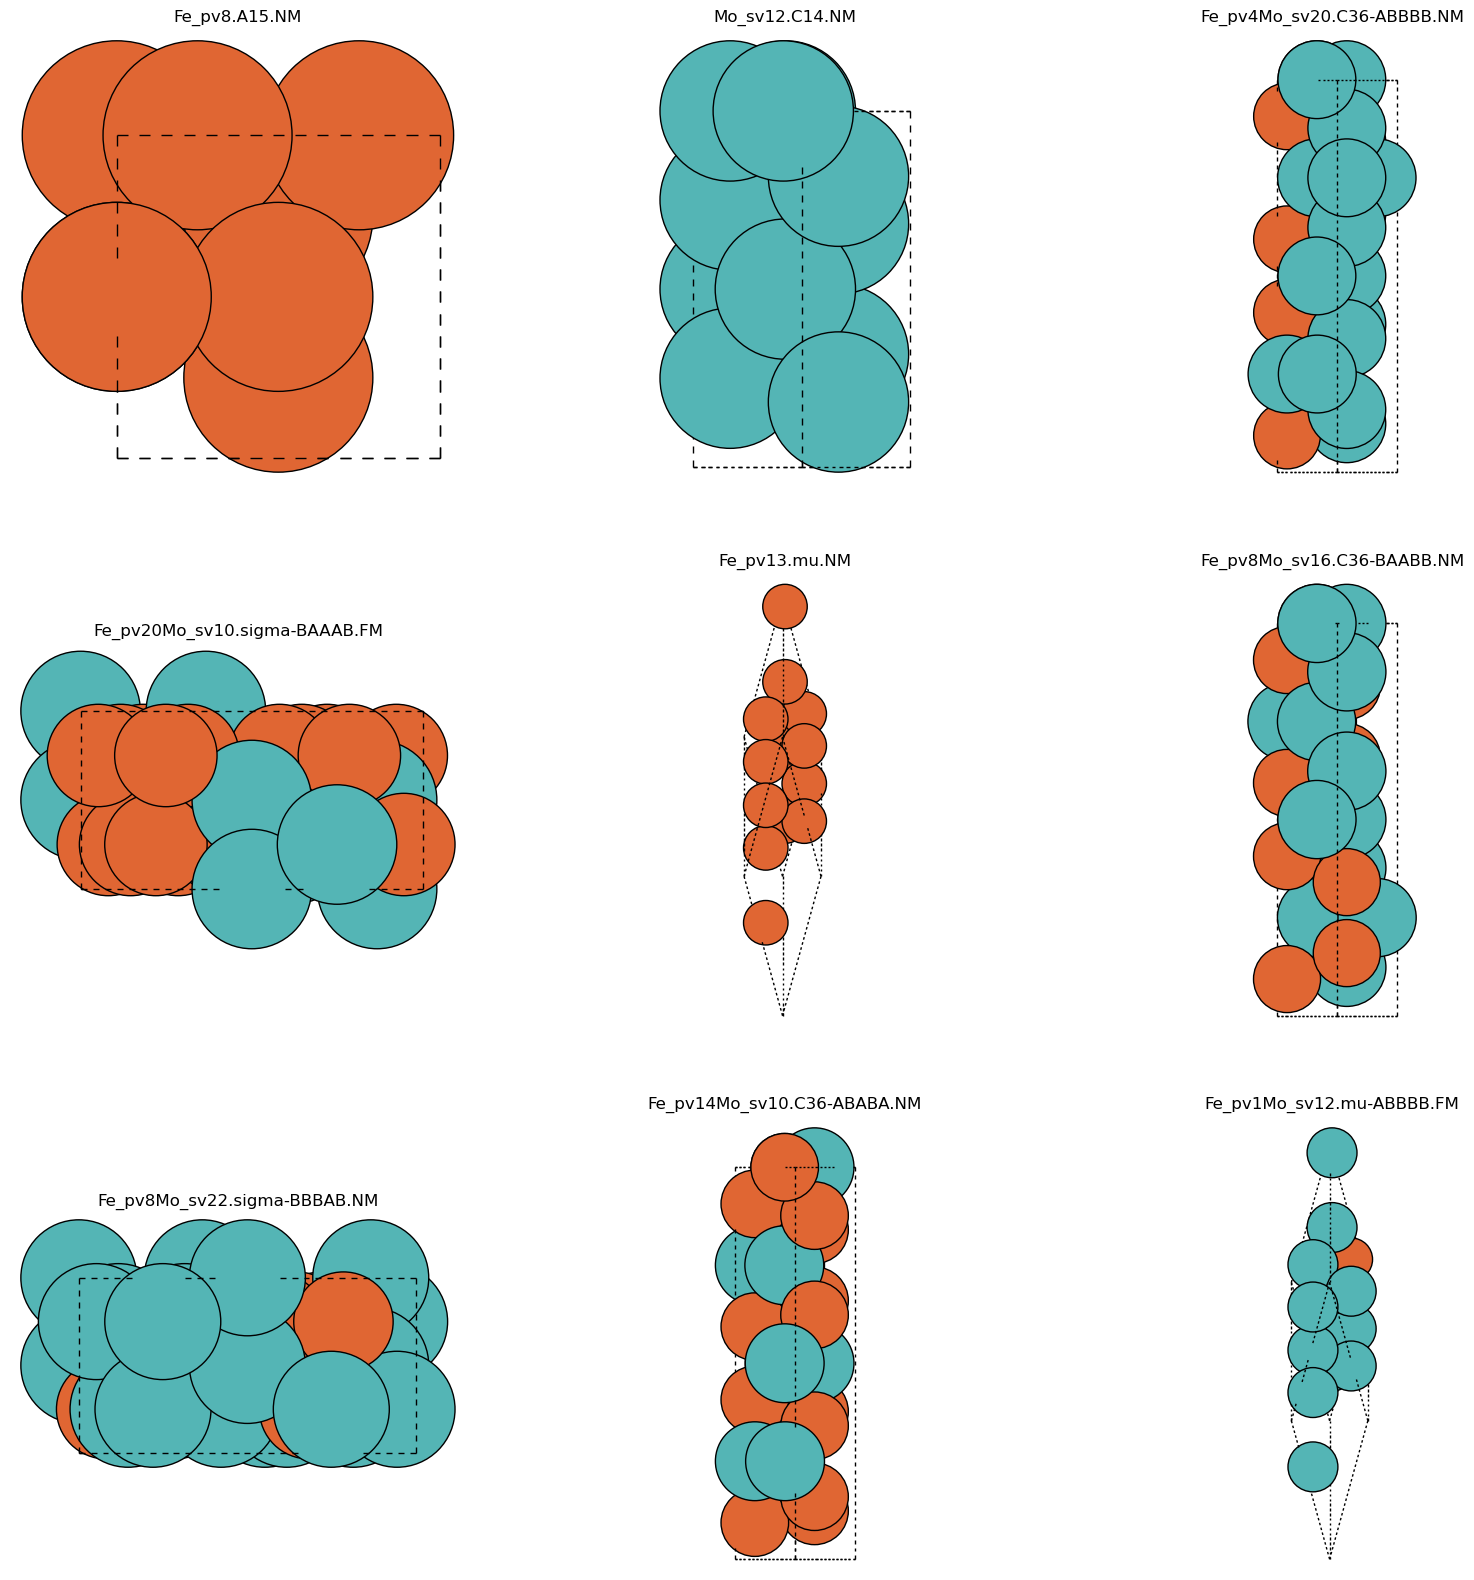

In [17]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, atoms_samples.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation = '90x')
#    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

In [18]:
somesigmas = Atoms_Objects.atoms[Atoms_Objects.index.str.contains('sigma')].sample(n=9)

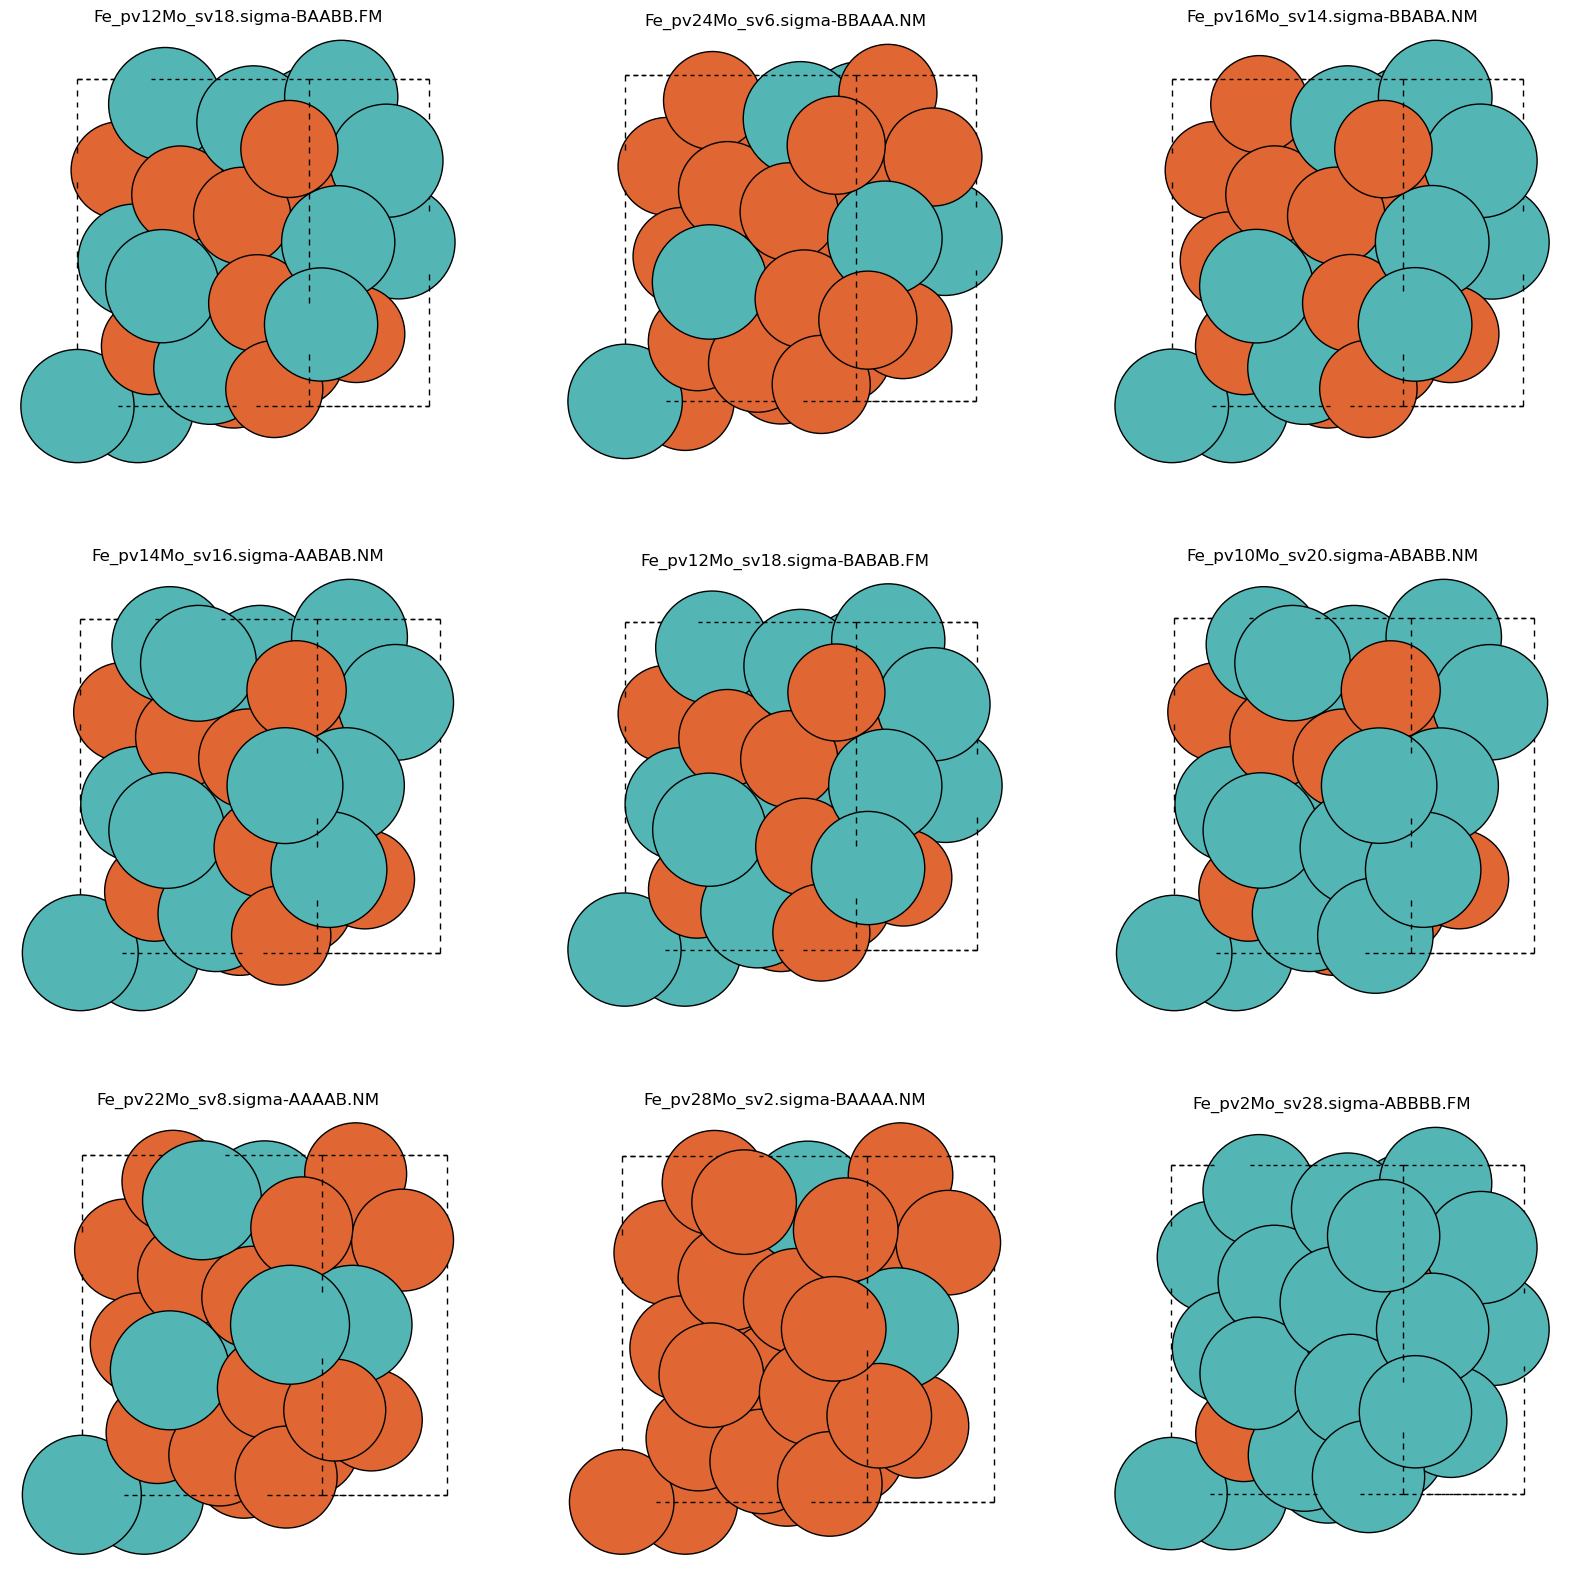

In [19]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, somesigmas.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation='90y, 90x, 45y')
    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

 For the actual visualization of the structures, we should choose one example for each structure and then draw in Vesta or Ovito for good quality figures, including coordination polyhedra etc.

# Curate Dataset to available structures 

There are still some R structures not available in data but present in briefsummaries

In [20]:
Problems = BS.index.difference(Atoms_Objects.index)

In [21]:
BS.loc[Problems]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Fe_pv,Mo_sv,EF,Phase
index,,,,,,,,,,,,,,,,,,,,,


In [22]:
GoodBS = BS.loc[Atoms_Objects.index]

In [23]:
GoodBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Fe_pv,Mo_sv,EF,Phase
index,,,,,,,,,,,,,,,,,,,,,
Fe_pv8Mo_sv22.sigma-BBABB.FM,bulk sigma-BBABB.FM,14.954763 A,-10.004507,224.285410 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,8,22,0,30.0,0.266667,0.733333,0.215379,sigma
Fe_pv10Mo_sv20.sigma-ABBAB.FM,bulk sigma-ABBAB.FM,14.130625 A,-10.006896,237.907324 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,10,20,0,30.0,0.333333,0.666667,0.034391,sigma
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,4,20,0,24.0,0.166667,0.833333,0.479948,C36
Fe_pv3Mo_sv10.mu-ABBBA.FM,bulk mu-ABBBA.FM,15.378254 A,-10.008565,402.123952 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,3,10,0,13.0,0.230769,0.769231,0.30749,mu
Fe_pv5Mo_sv24.chi-AABB.FM,bulk chi-AABB.FM,15.751001 A,-10.015010,216.183583 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,5,24,0,29.0,0.172414,0.827586,0.457378,chi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,bulk mu-ABBBA,15.125643 A,-9.973264,240.020984 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,3,10,0,13.0,0.230769,0.769231,0.342791,mu
Fe_pv8Mo_sv22.sigma-BBABB.NM,bulk sigma-BBABB,14.698886 A,-9.976143,247.238692 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,8,22,0,30.0,0.266667,0.733333,0.243743,sigma
Fe_pv1Mo_sv3.L12-AB3.FM,bulk L12-AB3.FM,14.806728 A,-9.986411,223.435464 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,1,3,0,4.0,0.250000,0.750000,0.278125,fcc


In [24]:
FullyCuratedBSFile = os.path.join(dataset,'FullyCuratedParsedBriefSummary.pkl')

In [25]:
GoodBS.to_pickle(FullyCuratedBSFile)